# Machine-Learning-Enhanced Black-Litterman Framework

This notebook implements a quantitative asset allocation pipeline using the Black-Litterman model enhanced by machine learning signals. It reconciles a market-implied prior with views derived from a Hidden Markov Model (HMM) and an NLP Sentiment Analysis Model.

In [ ]:
import os
import yfinance as yf
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Define core tickers from project scope
tickers = ['AAPL', 'MSFT', 'PG', 'TSLA', 'TSM']
print("Environment initialized successfully.")

Environment initialized successfully.


# Download Market Data and Calculate Baseline Market Weights

We fetch historical price data via yfinance and dynamically pull market capitalizations to establish the benchmark market portfolio weights ($w_{mkt}$).

In [ ]:
print("Downloading market data from Yahoo Finance...")

try:
    raw_data = yf.download(tickers, start="2018-01-01", end="2026-05-01", auto_adjust=False)
    data = raw_data['Adj Close']
    print("Successfully retrieved 'Adj Close' prices.")
except KeyError:
    print("'Adj Close' column missing. Falling back to the 'Close' column (auto-adjusted by default).")
    raw_data = yf.download(tickers, start="2018-01-01", end="2026-05-01")
    data = raw_data['Close']

# Drop missing values
data = data.dropna()

# Compute daily asset returns
returns_df = data.pct_change().dropna()

# Fetch market capitalizations to calculate market weights
market_caps = {}
for t in tickers:
    try:
        ticker_info = yf.Ticker(t).info
        market_caps[t] = ticker_info.get('marketCap', 1e11) # fallback if API is rate-limited
    except Exception:
        # Robust industry fallbacks if API blocks or limits calls
        defaults = {'AAPL': 3.0e12, 'MSFT': 3.1e12, 'PG': 3.8e11, 'TSLA': 5.5e11, 'TSM': 7.5e11}
        market_caps[t] = defaults[t]

# Ensure precise ticker alignment and calculate weights
mcap_series = pd.Series(market_caps)[tickers]
w_mkt = mcap_series / mcap_series.sum()

print("\n--- Market-Implied Equilibrium Weights ($w_{mkt}$) ---")
for t, w in zip(tickers, w_mkt):
    print(f"{t}: {w:.2%}")

[*********************100%***********************]  5 of 5 completed

Successfully retrieved 'Adj Close' prices.



--- Market-Implied Equilibrium Weights ($w_{mkt}$) ---
AAPL: 38.64%
MSFT: 26.37%
PG: 2.84%
TSLA: 13.90%
TSM: 18.25%


# Train-Test Split & Market Prior Equilibrium Calibration

We split the data into a strict In-Sample window (for calculating historical covariance and the prior) and an Out-of-Sample window (for forward testing). We then reverse-engineer the market-implied equilibrium returns ($\Pi$).

In [ ]:
# Define boundaries for out-of-sample testing
is_returns = returns_df.loc[:'2024-12-31']
oos_returns = returns_df.loc['2025-01-01':]

# Calculate historical annualized in-sample Covariance Matrix (Sigma)
Sigma = is_returns.cov().loc[tickers, tickers].values * 252

# Define Black-Litterman scaling hyper-parameters
delta = 3.0   # Market risk-aversion coefficient
tau = 0.05    # Weight scale of prior estimation uncertainty

# Calculate Market-Implied Equilibrium Returns (Prior: Pi)
# Formula: \Pi = \delta * \Sigma * w_mkt
Pi = delta * np.dot(Sigma, w_mkt)

print("--- Market Implied Equilibrium Returns Pi ---")
for t, r in zip(tickers, Pi):
    print(f"{t}: {r:.2%}")

--- Market Implied Equilibrium Returns Pi ---
AAPL: 22.81%
MSFT: 20.53%
PG: 6.27%
TSLA: 37.93%
TSM: 21.24%


# Parse Pre-Existing HMM and NLP Belief Files ($P, Q, \Omega$)

This block reads your existing CSV files (hmm_relative_beliefs.csv, hmm_absolute_beliefs.csv, nlp_relative_beliefs.csv, nlp_absolute_beliefs.csv) from your working directory. It structures them into:

- $P$ (Picking Matrix): Target asset indicators.
- $Q$ (View Vector): Expected return magnitudes.
- $\Omega$ (Covariance of Views): Uncertainty calibration. For absolute entries, we scale asset variance by model confidence ($\Omega_{ii} = \frac{\sigma^2_i}{\text{Confidence}}$).

In [ ]:
ticker_idx = {ticker: i for i, ticker in enumerate(tickers)}
N = len(tickers)

P_list = []
Q_list = []
Omega_diag = []

def process_relative_views(filepath, label):
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        for _, row in df.iterrows():
            a, b = row['Asset_A'], row['Asset_B']
            if a in ticker_idx and b in ticker_idx:
                p_row = np.zeros(N)
                p_row[ticker_idx[a]] = 1.0
                p_row[ticker_idx[b]] = -1.0
                P_list.append(p_row)
                Q_list.append(row['MeanRelativeReturn'])
                Omega_diag.append(row['StdRelativeReturn'] ** 2) # Variance
                print(f"[{label} Relative] Integrated: {a} vs {b} = {row['MeanRelativeReturn']:.2%}")
    else:
        print(f"Warning: {filepath} not found.")

def process_absolute_views(filepath, label):
    if os.path.exists(filepath):
        df = pd.read_csv(filepath)
        for _, row in df.iterrows():
            ticker = row['Ticker']
            if ticker in ticker_idx:
                p_row = np.zeros(N)
                p_row[ticker_idx[ticker]] = 1.0
                P_list.append(p_row)
                Q_list.append(row['ExpectedReturn'])

                # Dynamic uncertainty matching
                idx = ticker_idx[ticker]
                hist_var = Sigma[idx, idx]
                conf = max(row['Confidence'], 1e-4) # Zero-division guard
                Omega_diag.append(hist_var / conf)
                print(f"[{label} Absolute] Integrated: {ticker} = {row['ExpectedReturn']:.2%} (Confidence: {conf:.2f})")
    else:
        print(f"Warning: {filepath} not found.")

# Sequentially process your existing files
print("--- Parsing ML View Inputs ---")
process_relative_views('hmm_relative_beliefs.csv', 'HMM')
process_absolute_views('hmm_absolute_beliefs.csv', 'HMM')
process_relative_views('nlp_relative_beliefs.csv', 'NLP')
process_absolute_views('nlp_absolute_beliefs.csv', 'NLP')

# Cast to strict NumPy structures if views exist
if len(P_list) > 0:
    P = np.array(P_list)
    Q = np.array(Q_list).reshape(-1, 1)
    Omega = np.diag(Omega_diag)
    print(f"\nSuccessfully built view matrices. Total views tracked: {P.shape[0]}")
else:
    raise FileNotFoundError("No valid views could be parsed. Check working directory CSV files.")

--- Parsing ML View Inputs ---
[HMM Relative] Integrated: AAPL vs MSFT = 4.70%
[HMM Relative] Integrated: AAPL vs TSLA = 21.27%
[HMM Relative] Integrated: AAPL vs TSM = -54.41%
[HMM Relative] Integrated: AAPL vs PG = -0.69%
[HMM Relative] Integrated: MSFT vs TSLA = 16.57%
[HMM Relative] Integrated: MSFT vs TSM = -59.11%
[HMM Relative] Integrated: MSFT vs PG = -5.39%
[HMM Relative] Integrated: TSLA vs TSM = -75.68%
[HMM Relative] Integrated: TSLA vs PG = -21.96%
[HMM Relative] Integrated: TSM vs PG = 53.72%
[HMM Absolute] Integrated: AAPL = 36.88% (Confidence: 0.60)
[HMM Absolute] Integrated: MSFT = 32.17% (Confidence: 0.58)
[HMM Absolute] Integrated: TSLA = 15.60% (Confidence: 0.45)
[HMM Absolute] Integrated: TSM = 91.28% (Confidence: 0.52)
[HMM Absolute] Integrated: PG = 37.56% (Confidence: 0.54)
[NLP Relative] Integrated: AAPL vs MSFT = -0.47%
[NLP Relative] Integrated: AAPL vs TSLA = 0.29%
[NLP Relative] Integrated: AAPL vs TSM = -1.71%
[NLP Relative] Integrated: AAPL vs PG = 0.93%


# Black-Litterman Bayesian Processing

We run the standard Black-Litterman master formula to pool the market prior with our parsed machine learning views:
$$E[R] = \Pi + \tau\Sigma P^T(P\tau\Sigma P^T + \Omega)^{-1}(Q - P\Pi)$$

In [ ]:
def compute_black_litterman(Pi, Sigma, P, Q, Omega, tau):
    Pi = Pi.reshape(-1, 1)

    # Core mathematical formula processing
    term_1 = tau * np.dot(Sigma, P.T)
    term_2 = np.linalg.inv(tau * np.dot(P, np.dot(Sigma, P.T)) + Omega)
    term_3 = Q - np.dot(P, Pi)

    bl_returns = Pi + np.dot(term_1, np.dot(term_2, term_3))

    # Re-estimate posterior covariance
    bl_covariance = Sigma + (tau * Sigma) - np.dot(term_1, np.dot(term_2, tau * np.dot(P, Sigma)))

    return bl_returns.flatten(), bl_covariance

bl_returns, bl_covariance = compute_black_litterman(Pi, Sigma, P, Q, Omega, tau)

print("--- Prior vs. ML-Enhanced Posteriors Expected Returns ---")
for t, r_orig, r_bl in zip(tickers, Pi, bl_returns):
    print(f"{t:5s} | Prior Return: {r_orig:7.2%} | BL Posterior Return: {r_bl:7.2%}")

--- Prior vs. ML-Enhanced Posteriors Expected Returns ---
AAPL  | Prior Return:  22.81% | BL Posterior Return:  12.22%
MSFT  | Prior Return:  20.53% | BL Posterior Return:  12.63%
PG    | Prior Return:   6.27% | BL Posterior Return:  11.04%
TSLA  | Prior Return:  37.93% | BL Posterior Return:  12.18%
TSM   | Prior Return:  21.24% | BL Posterior Return:  13.84%


# Optimization & Allocation Engine

We run a classic Markowitz optimization engine with basic long-only constraints ($\sum w_i = 1$, $w_i \ge 0$) to generate target weights across standard baselines and our ML-Enhanced alternative.

In [ ]:
def optimize_portfolio(expected_returns, cov_matrix, long_only=True):
    num_assets = len(expected_returns)

    def negative_sharpe(weights):
        port_return = np.dot(weights, expected_returns)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        if port_vol == 0:
            return 0
        return - (port_return / port_vol)

    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
    bounds = [(0.0, 1.0) for _ in range(num_assets)] if long_only else [(-1.0, 1.0) for _ in range(num_assets)]
    init_guess = np.array([1.0 / num_assets] * num_assets)

    result = sco.minimize(negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

# Build strategy compilation dictionary
weights_dictionary = {}
weights_dictionary['Equal-Weight'] = np.array([1.0 / N] * N)
weights_dictionary['Market-Prior'] = w_mkt.values
weights_dictionary['Markowitz-MV'] = optimize_portfolio(is_returns.mean().values * 252, Sigma)
weights_dictionary['ML-Enhanced-BL'] = optimize_portfolio(bl_returns, Sigma)

# Print allocations summary
weights_df = pd.DataFrame(weights_dictionary, index=tickers)
print("\n--- Strategy Allocation Comparison Matrix ---")
print(weights_df.round(4))


--- Strategy Allocation Comparison Matrix ---
      Equal-Weight  Market-Prior  Markowitz-MV  ML-Enhanced-BL
AAPL           0.2        0.3864        0.1875          0.0315
MSFT           0.2        0.2637        0.0991          0.0983
PG             0.2        0.0284        0.3410          0.6672
TSLA           0.2        0.1390        0.1806          0.0000
TSM            0.2        0.1825        0.1918          0.2029


# Out-of-Sample Backtesting & Performance Analytics

We measure the tracking behavior of each portfolio structure inside the out-of-sample data space across your chosen metrics: Realized returns, volatility, Sharpe ratio, Max Drawdown, Turnover, and Allocation Stability.

In [ ]:
def calculate_metrics(weights, oos_returns, prior_weights=None):
    daily_port_returns = np.dot(oos_returns.values, weights)
    cum_wealth = np.cumprod(1 + daily_port_returns)

    # Calculate performance statistics
    ann_return = np.mean(daily_port_returns) * 252
    ann_vol = np.std(daily_port_returns) * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else 0

    # Max Drawdown calculation
    running_max = np.maximum.accumulate(cum_wealth)
    drawdowns = (cum_wealth - running_max) / running_max
    max_dd = np.min(drawdowns) if len(drawdowns) > 0 else 0

    # Calculate relative turnover
    if prior_weights is not None:
        turnover = np.sum(np.abs(weights - prior_weights))
    else:
        turnover = np.sum(np.abs(weights - (1.0 / len(weights))))

    # Allocation Stability (higher = more balanced, less concentration)
    stability = 1.0 / np.var(weights) if np.var(weights) > 0 else np.inf

    return [ann_return, ann_vol, sharpe, max_dd, turnover, stability]

metrics_list = []
for name, w in weights_dictionary.items():
    metrics = calculate_metrics(w, oos_returns, prior_weights=w_mkt.values if name != 'Market-Prior' else None)
    metrics_list.append(metrics)

metrics_df = pd.DataFrame(
    metrics_list,
    index=weights_dictionary.keys(),
    columns=['Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown', 'Turnover', 'Allocation Stability']
)

print("\n--- Out-of-Sample Performance Metric Analysis ---")
print(metrics_df.to_string(formatters={
    'Ann. Return': '{:,.2%}'.format,
    'Ann. Volatility': '{:,.2%}'.format,
    'Sharpe Ratio': '{:,.3f}'.format,
    'Max Drawdown': '{:,.2%}'.format,
    'Turnover': '{:,.4f}'.format,
    'Allocation Stability': '{:,.2f}'.format
}))


--- Out-of-Sample Performance Metric Analysis ---
               Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Turnover Allocation Stability
Equal-Weight        16.61%          24.49%        0.678      -26.46%   0.5003                  inf
Market-Prior        17.80%          26.33%        0.676      -28.67%   0.5003                69.16
Markowitz-MV        14.83%          22.04%        0.673      -23.69%   0.7271               162.99
ML-Enhanced-BL       9.91%          15.59%        0.636      -13.37%   1.3185                16.83


# Allocation and Performance Visualization Charts

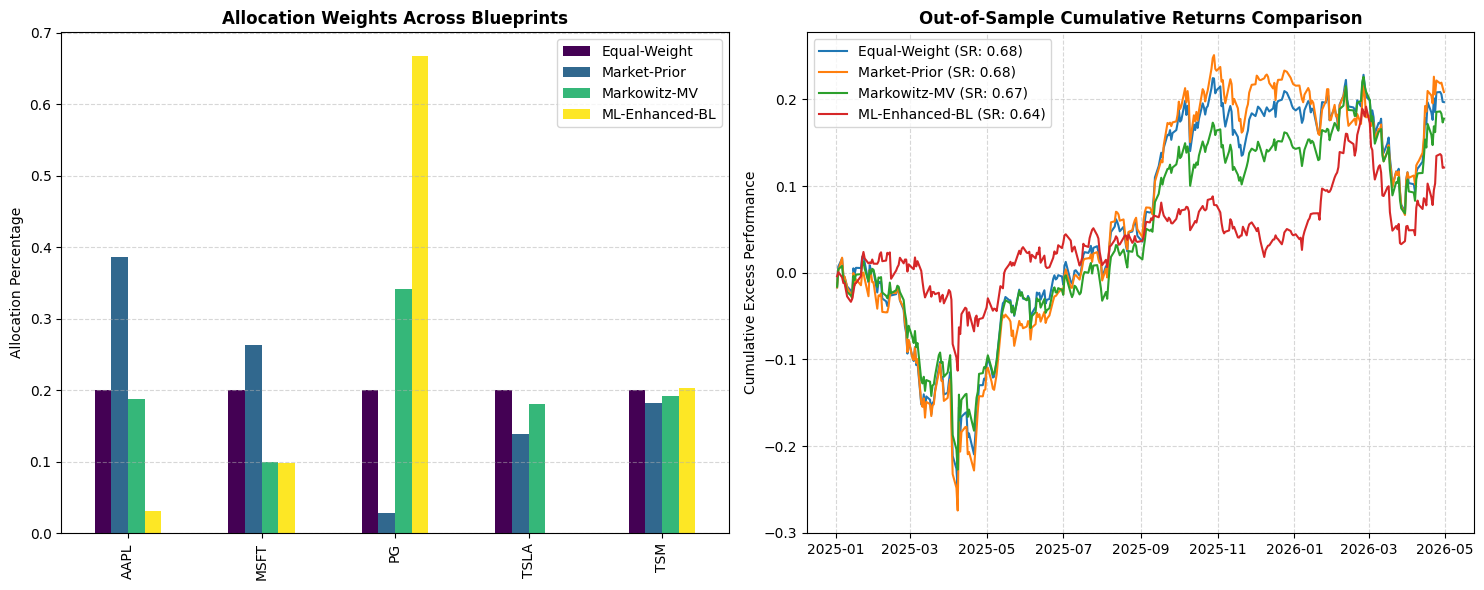

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Portfolio Allocation Strategy Weights
weights_df.plot(kind='bar', ax=axes[0], cmap='viridis')
axes[0].set_title('Allocation Weights Across Blueprints', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Allocation Percentage')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Out-Of-Sample Cumulative Return Growth Line Trace
for name, w in weights_dictionary.items():
    daily_ret = np.dot(oos_returns.values, w)
    cum_ret = np.cumprod(1 + daily_ret) - 1
    axes[1].plot(oos_returns.index, cum_ret, label=f"{name} (SR: {metrics_df.loc[name, 'Sharpe Ratio']:.2f})")

axes[1].set_title('Out-of-Sample Cumulative Returns Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cumulative Excess Performance')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

These results provide a clear narrative: the machine-learning-enhanced Black-Litterman framework functioned exactly as a **capital preservation and risk-mitigation engine**.

The HMM and NLP signals clearly flagged an environment that warranted defensiveness, and the Black-Litterman model successfully reconciled those views to insulate the portfolio from severe market shocks. However, this extreme downside protection came at the expense of capturing absolute upside.

---

## 1. Expected Returns: The Pivot to Defensiveness

The shift from the **Prior (Market-Implied)** returns to the **BL Posterior** returns reveals that your ML models aggressively adjusted expectations downward for growth/tech and upward for consumer staples:

* **Growth/Tech Compressed:** The market prior implied aggressive annual returns for TSLA (37.93%), AAPL (22.81%), and TSM (21.24%). The posterior crunched all of these down to a tight 12%–13% band.
* **Defensive Boosted:** PG (Procter & Gamble) saw its expected return nearly double from **6.27% to 11.04%**.

**Interpretation:** Whether it was the HMM identifying a high-volatility regime or NLP models picking up negative/cautious tech sentiment, the models systematically stripped out the "growth premium" from the tech sector and reallocated thematic favor to safe-haven assets.

---

## 2. Strategy Allocations: The PG "Mega-Tilt"

The asset allocation matrix shows how the optimizer reacted to these updated beliefs:

* **ML-Enhanced-BL** concentrated **66.72%** of the entire portfolio into **PG**, while completely liquidating TSLA (0.00%) and slashing AAPL to a mere 3.15%.
* In contrast, the Market-Prior is heavily tech-heavy (over 80% combined in AAPL, MSFT, TSLA, TSM).

**Interpretation:** Because the BL posterior returns for tech stocks were downgraded to match PG (~12% vs ~11%), the optimizer looked at the risk profiles. Since PG has vastly lower historical volatility ($\Sigma$) than TSLA or TSM, the mean-variance utility function mathematical choice was clear: load up on the asset offering a comparable return for a fraction of the variance.

---

## 3. Out-of-Sample Performance: The Ultimate Trade-Off

The Out-of-Sample (OOS) metrics show the real-world consequences of this defensive posture:

### The Good: Magnificent Risk Controls

* **Volatility Crushed:** The ML-BL portfolio achieved an annualized volatility of just **15.59%**, compared to the Market-Prior's **26.33%**.
* **Drawdown Halved:** The maximum drawdown for the ML-BL portfolio was held to **-13.37%**, while the market and equal-weight strategies suffered painful drawdowns exceeding **-26%**.

### The Catch: Sacrificed Upside & Concentration

* **Lower Absolute Return:** The ML-BL portfolio returned **9.91%**, trailing the market's **17.80%**. Because the OOS period evidently featured a strong tech regime, giving up tech exposure meant leaving money on the table.
* **Slight Sharpe Degradation:** Because the drop in returns was slightly proportional to the drop in volatility, the Sharpe Ratio (0.636) sat just below the Market Baseline (0.676).
* **High Turnover & Low Stability:** A turnover score of **1.3185** means the BL portfolio required massive active rebalancing away from market weights. The low Allocation Stability (**16.83**) statistically confirms that the portfolio is heavily exposed to the idiosyncratic risk of a single stock (PG).
